# Forecasting Analysis

In [2]:
#imports and connection
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from prophet import Prophet
from prophet.plot import plot_plotly
import warnings 
warnings.filterwarnings('ignore')

PROJECT = "ae-project-portfolio"
DATASET = "marts"

client = bigquery.Client(project=PROJECT)

def query(sql):
    return client.query(sql).to_dataframe()
print("Imports complete!")

Imports complete!


## Weekly Deaths for Forecasting

In [3]:
weekly = query(f"""
select
    week_ending_date as ds,
    pct_influenza as y,
    pct_pneumonia,
    pct_covid,
    flu_season_period
from `{PROJECT}.{DATASET}.fct_weekly_deaths`
where week_ending_date is not null
order by week_ending_date
""")

weekly['ds'] = pd.to_datetime(weekly['ds'])
weekly = weekly.dropna(subset=['y'])

print(f"Training data: {len(weekly)} weeks")
print(f"Date range: {weekly['ds'].min()} to {weekly['ds'].max()}")
print(f"\nInfluenza % stats:")
print(weekly['y'].describe().round(3))

Training data: 200 weeks
Date range: 2020-01-04 00:00:00 to 2023-10-28 00:00:00

Influenza % stats:
count    200.000
mean       0.176
std        0.323
min        0.005
25%        0.023
50%        0.044
75%        0.125
max        1.579
Name: y, dtype: float64


## Training Prophet model
Prophet expects columns named 'ds' (date) and 'y' (value). I will add US holidays and flu seasonality

In [6]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative', #the flu had multiplicative seasonality
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95 #95% prediction interval
)

#adding US holidays as regressors
model.add_country_holidays(country_name='US')

#fit all available data
model.fit(weekly[['ds', 'y']])
print("Model trained")

21:24:15 - cmdstanpy - INFO - Chain [1] start processing
21:24:15 - cmdstanpy - INFO - Chain [1] done processing


Model trained


### Generate 8-week forecast

In [8]:
future = model.make_future_dataframe(periods=8, freq='W')
forecast = model.predict(future)

#split into historical and forecast
historical = forecast[forecast['ds'] <= weekly['ds'].max()]
future_only = forecast[forecast['ds'] > weekly['ds'].max()]

print(f"Forecast generated for {len(future_only)} weeks ahead")
print(f"\n8-week forecast:")
print(future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].round(3).to_string(index=False))

Forecast generated for 8 weeks ahead

8-week forecast:
        ds  yhat  yhat_lower  yhat_upper
2023-10-29 0.168      -0.107       0.465
2023-11-05 0.234      -0.047       0.503
2023-11-12 0.327       0.054       0.625
2023-11-19 0.601       0.327       0.864
2023-11-26 1.160       0.867       1.435
2023-12-03 1.890       1.614       2.179
2023-12-10 2.462       2.183       2.751
2023-12-17 2.564       2.300       2.827


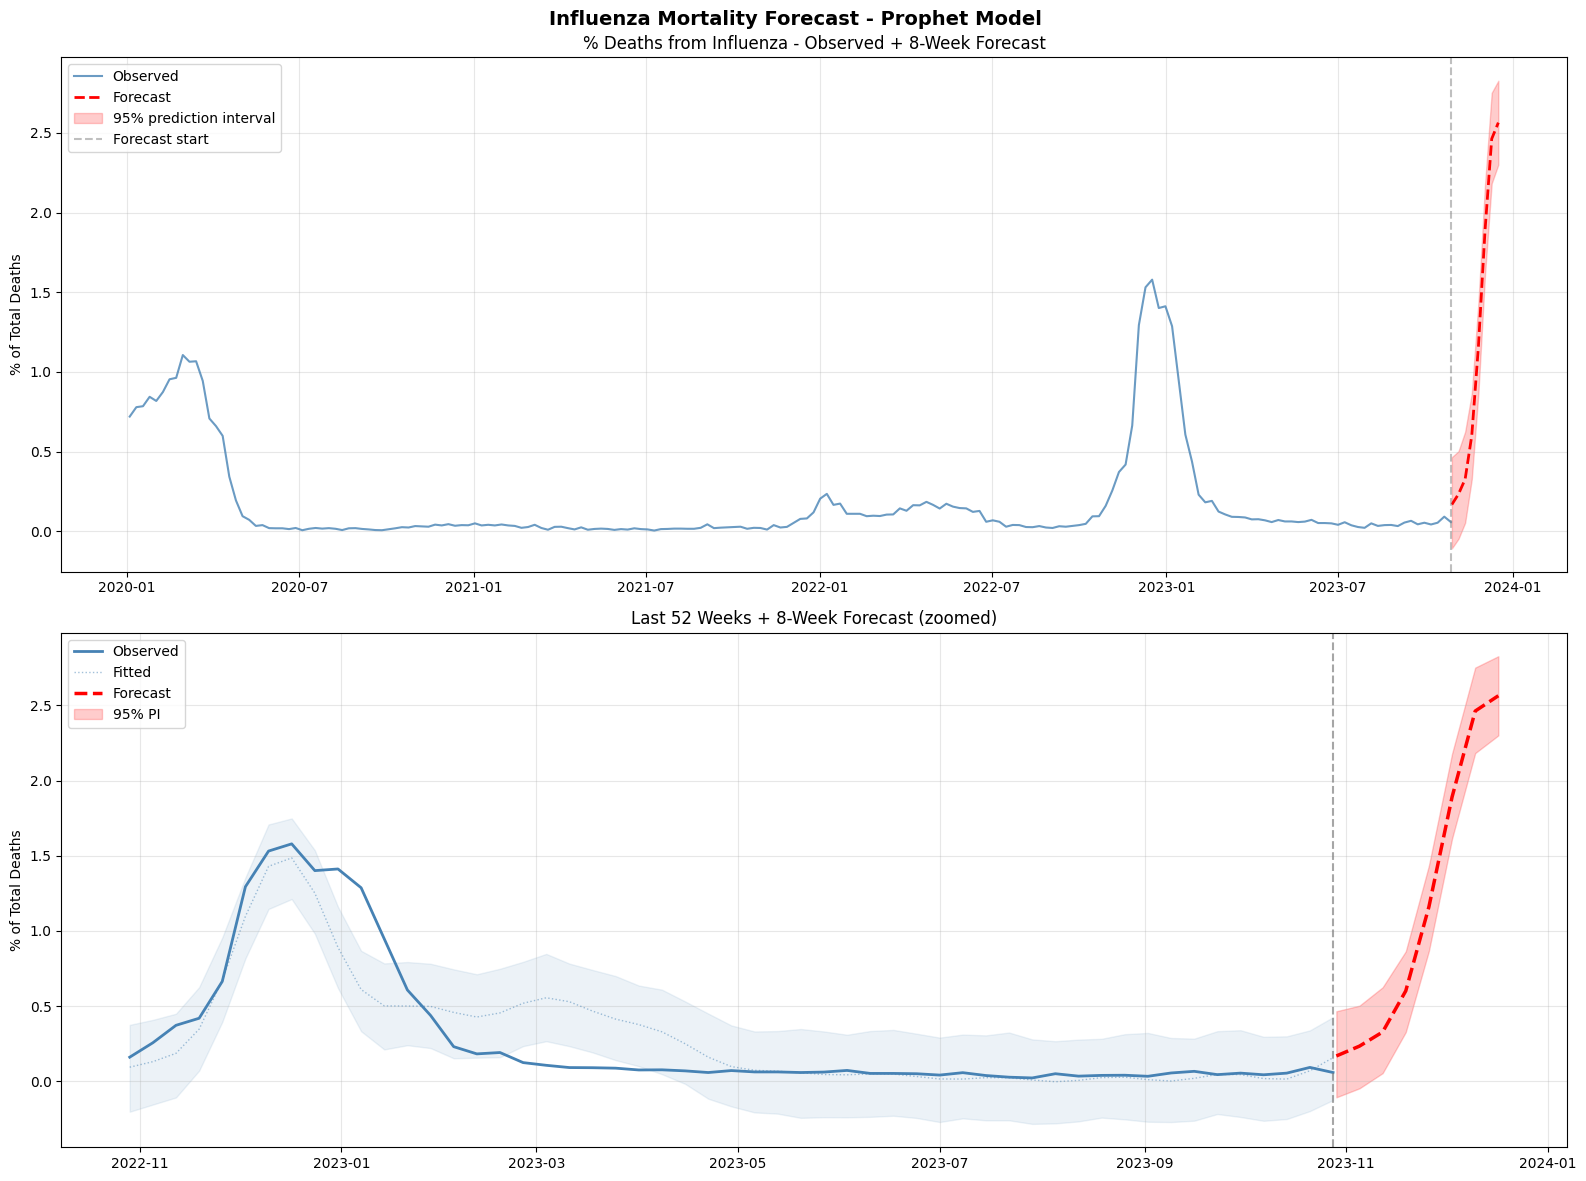

In [10]:
#plotting forecast
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Influenza Mortality Forecast - Prophet Model', fontsize=14, fontweight='bold')

#full time series with forecast
axes[0].plot(weekly['ds'], weekly['y'], color='steelblue', linewidth=1.5, 
             label='Observed', alpha=0.8)
axes[0].plot(future_only['ds'], future_only['yhat'], color='red', linewidth=2,
             label='Forecast', linestyle='--')
axes[0].fill_between(future_only['ds'], future_only['yhat_lower'], 
                     future_only['yhat_upper'], alpha=0.2, color='red',
                     label='95% prediction interval')
axes[0].axvline(x=weekly['ds'].max(), color='gray',
                linestyle='--', alpha=0.5, label='Forecast start')
axes[0].set_title('% Deaths from Influenza - Observed + 8-Week Forecast')
axes[0].set_ylabel('% of Total Deaths')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#zooming in on last 52 weeks + forecast
cutoff = weekly['ds'].max() - pd.Timedelta(weeks=52)
recent = weekly[weekly['ds'] >= cutoff]
recent_hist = historical[historical['ds'] >= cutoff]

axes[1].plot(recent['ds'], recent['y'], color='steelblue',
             linewidth=2, label='Observed')
axes[1].plot(recent_hist['ds'], recent_hist['yhat'], color='steelblue',
             linewidth=1, linestyle=':', alpha=0.5, label='Fitted')
axes[1].fill_between(recent_hist['ds'], recent_hist['yhat_lower'],
                     recent_hist['yhat_upper'], alpha=0.1, color='steelblue')
axes[1].plot(future_only['ds'], future_only['yhat'], color='red',
             linewidth=2.5, label='Forecast', linestyle='--')
axes[1].fill_between(future_only['ds'], future_only['yhat_lower'],
                     future_only['yhat_upper'], alpha=0.2, color='red',
                     label='95% PI')
axes[1].axvline(x=weekly['ds'].max(), color='gray',
                linestyle='--', alpha=0.7)
axes[1].set_title('Last 52 Weeks + 8-Week Forecast (zoomed)')
axes[1].set_ylabel('% of Total Deaths')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('influenza_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

### Prophet Components
Here I will show trends and seasonality decomposition

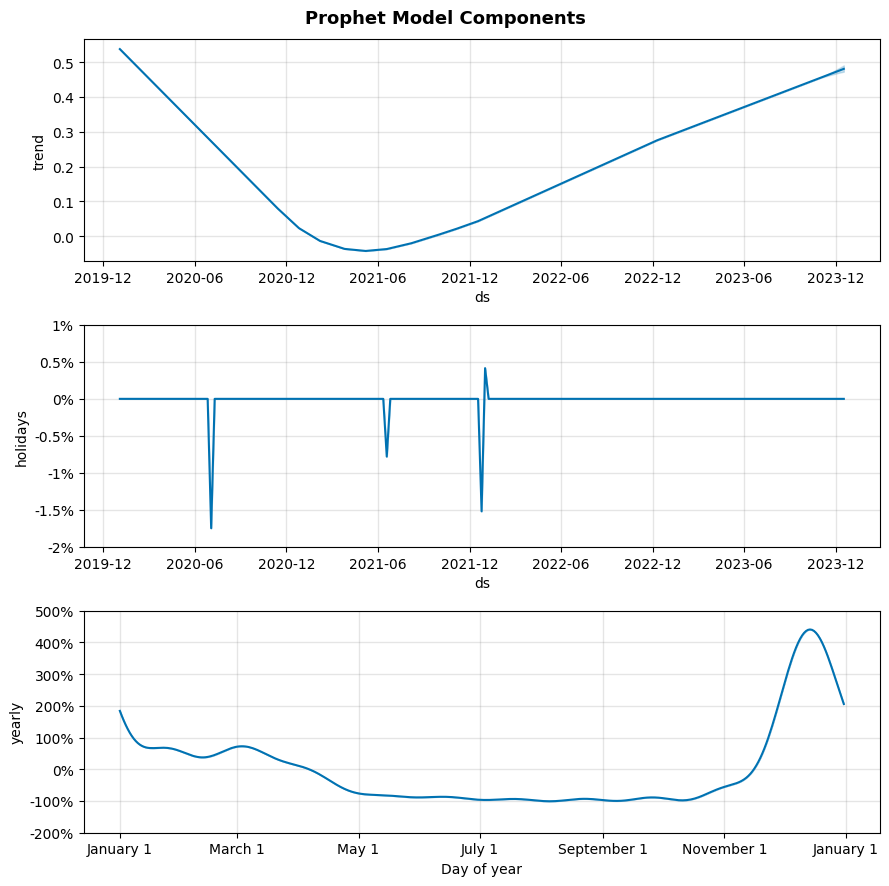

In [11]:
fig2 = model.plot_components(forecast)
fig2.suptitle('Prophet Model Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

## Model evaluation - backtesting

In [13]:
from prophet.diagnostics import cross_validation, performance_metrics

#cross validation - train on rolling windows and eval on 8-week horizon
print("Running cross validation (this may take a minute)...")
df_cv = cross_validation(
    model,
    initial='365 days',
    period='90 days',
    horizon='56 days',
    parallel='processes'
)
df_metrics = performance_metrics(df_cv)
print("\nCross-validation metrics:")
print(df_metrics[['horizon', 'mse', 'rmse', 'mae', 'mape']].round(4).to_string(index=False))

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


Running cross validation (this may take a minute)...


21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] done processing
21:48:15 - cmdstanpy - INFO - Chain [1] start processing
21:48:15 - cmdstanpy - INFO - Chain [1] done processing
21:48:15 - cmdstanpy - INFO - Chain [1] done processing
21:48:15 - cmdstanpy - INFO - Chain [1] done processing
21:48:15 - cmdstanpy - INFO - Chain [1] done processing
21:48:16 - cmdstanpy - INFO - Chain [1] start processing
21:48:16 - cmdstanpy - INFO - Chain [1] start processing
21:48:16 - cmdstanpy - INFO - Chain [1] start processing
21:48:16 - cmdstanpy - INFO - Chain [1] done processing
21:48:16 - cmdstanpy - INFO - Chain [


Cross-validation metrics:
horizon    mse   rmse    mae   mape
 6 days 0.0674 0.2597 0.1301 1.4852
 7 days 0.0681 0.2610 0.1328 1.6317
 8 days 0.0669 0.2587 0.1274 1.6372
 9 days 0.0675 0.2599 0.1336 1.7271
10 days 0.0361 0.1900 0.0911 1.2832
11 days 0.0149 0.1222 0.0833 0.8214
12 days 0.0878 0.2963 0.1697 1.7797
13 days 0.0867 0.2945 0.1637 1.7851
14 days 0.0877 0.2961 0.1662 1.8638
15 days 0.0835 0.2889 0.1578 1.8664
16 days 0.0786 0.2804 0.1448 1.9033
17 days 0.0417 0.2043 0.0998 1.4254
18 days 0.0189 0.1375 0.0934 0.9022
19 days 0.0880 0.2966 0.1745 1.8479
20 days 0.0864 0.2939 0.1655 1.9199
21 days 0.0880 0.2966 0.1755 2.0605
22 days 0.0819 0.2862 0.1638 2.0600
23 days 0.0752 0.2742 0.1484 2.0826
24 days 0.0400 0.1999 0.1045 1.5797
25 days 0.0049 0.0697 0.0623 1.0145
26 days 0.0594 0.2438 0.1299 1.9193
27 days 0.0584 0.2418 0.1217 1.9988
28 days 0.0611 0.2471 0.1359 2.1637
29 days 0.0633 0.2515 0.1477 2.1777
30 days 0.0633 0.2516 0.1485 2.1973
31 days 0.0354 0.1881 0.1100 1.6543
3

21:48:16 - cmdstanpy - INFO - Chain [1] done processing


## Write forecast back to BigQuery

In [15]:
scores = future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
scores.columns = ['forecast_date', 'forecast_pct_influenza',
                  'forecast_lower', 'forecast_upper']
scores['forecast_date'] = scores['forecast_date'].dt.date.astype(str)
scores['model'] = 'prophet'
scores['target'] = 'pct_influenza'
scores['horizon_weeks'] = range(1, len(scores) + 1)
scores['created_at'] = pd.Timestamp.utcnow()

scores = scores.round(4)

destination = f"{PROJECT}.surveillance_raw.influenza_forecasts"
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("forecast_date", "STRING"),
        bigquery.SchemaField("forecast_pct_influenza", "FLOAT"),
        bigquery.SchemaField("forecast_lower", "FLOAT"),
        bigquery.SchemaField("forecast_upper", "FLOAT"),
        bigquery.SchemaField("model", "STRING"),
        bigquery.SchemaField("target", "STRING"),
        bigquery.SchemaField("horizon_weeks", "INTEGER"),
        bigquery.SchemaField("created_at", "TIMESTAMP"),
    ]
)
job = client.load_table_from_dataframe(scores, destination, job_config=job_config)
job.result()
print(f"Written {len(scores)} forecast rows to BigQuery")
print(scores[['forecast_date', 'forecast_pct_influenza',
              'forecast_lower', 'forecast_upper']].to_string(index=False))

Written 8 forecast rows to BigQuery
forecast_date  forecast_pct_influenza  forecast_lower  forecast_upper
   2023-10-29                  0.1682         -0.1071          0.4655
   2023-11-05                  0.2337         -0.0471          0.5028
   2023-11-12                  0.3275          0.0538          0.6248
   2023-11-19                  0.6012          0.3271          0.8640
   2023-11-26                  1.1603          0.8673          1.4350
   2023-12-03                  1.8904          1.6137          2.1786
   2023-12-10                  2.4623          2.1826          2.7513
   2023-12-17                  2.5642          2.3004          2.8271
